## FD 2 layers data generator part 1


In [ ]:
! pip install pmcx
! pip install numpy pmcx jdata bjdata matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pickle
import math
import io

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path to your folder containing the .py script
folder_path = '/content/drive/MyDrive/MCX_data'
sys.path.append(folder_path)
from cw_nirs import mcx_sim_2layers as ms2

### Read CSV and coef

In [ ]:
# csv file to simulate: change the path!.
csv_path = '/content/drive/MyDrive/MCX_data/cw_stage1_csv/stage1_part_15.csv'
df = pd.read_csv(csv_path)
# simulations save path
save_path = '/content/drive/MyDrive/MCX_data/result_folder/cw_stage1/part15/'

In [ ]:
lambdas = list(range(750, 951, 2))
coef_path = '/content/drive/MyDrive/MCX_data/EC.xlsx'
extinction_coeffs = pd.read_excel(coef_path)

In [ ]:
extinction_coeffs.head()

,Lambda,HbO2,Hb,CCO,fat,water,oxCCO,redCCO,redox,Water,water2
0,650,386.80,3734.15,4929.24,4.71,3.20117,6910.0,3350.0,3560.0,0.001608,
1,651,379.20,3702.97,4892.33,4.72,3.22420,6850.0,3310.0,3540.0,0.001634,NaN
2,652,372.10,3671.79,4855.41,4.67,3.33935,6810.0,3270.0,3540.0,0.001651,NaN
3,653,365.81,3640.47,4806.77,4.64,3.31632,6760.0,3240.0,3520.0,0.001663,NaN
4,654,360.01,3611.68,4758.13,4.57,3.38541,6720.0,3210.0,3510.0,0.001711,NaN


In [ ]:
part_str = csv_path.split('/')[-1].replace('.csv', '').split('_')[-2] + '_' + csv_path.split('_')[-1].replace('.csv', '')
print(part_str)
# make in to be .1
df['d1'] = df['d1'].round(0)

part_1


In [ ]:
df.head()

,HBO1,HHB1,CCO1,HBO2,HHB2,CCO2,d1,a1,a2,b1,b2,ID
0,10.618102,12.007143,1.097991,42.959755,18.120373,2.339918,11.0,6.097057,2.963457,1.799374,0.361753,1
1,18.118102,7.007143,0.347991,27.959755,28.120373,9.839918,16.0,3.097057,1.413457,0.599374,1.861753,2
2,6.868102,4.507143,0.722991,50.459755,33.120373,6.089918,18.0,1.597057,3.738457,1.199374,1.111753,3
3,14.368102,9.507143,1.472991,35.459755,23.120373,13.589918,13.0,4.597057,2.188457,2.399374,2.611753,4
4,16.243102,5.757143,0.535491,46.709755,15.620373,0.464918,12.0,3.847057,3.350957,1.499374,1.486753,5


### Generate data using package

In [ ]:
import os

# List all .pkl files in the folder
existing_files = [f for f in os.listdir(save_path) if f.endswith('.pkl')]

# Extract numeric IDs from filenames like "123.pkl"
existing_ids = [int(f.replace('.pkl', '')) for f in existing_files if f.replace('.pkl', '').isdigit()]

if existing_ids:
    next_id = max(existing_ids) + 1
else:
    next_id = min_id = df['ID'].min()

print(f'Next ID to run: {next_id}')

Next ID to run: 3


In [ ]:
import pickle

In [ ]:
min_id = df['ID'].min()
max_id = df['ID'].max()

for i in range (next_id, max_id+1):
  first_row = df[df['ID'] == i].iloc[0]
  HBO1=first_row['HBO1']
  HHB1=first_row['HHB1']
  CCO1=first_row['CCO1']
  HBO2=first_row['HBO2']
  HHB2=first_row['HHB2']
  CCO2=first_row['CCO2']
  # Other properties
  d1=first_row['d1']
  a1=first_row['a1']
  a2=first_row['a2']
  b1=first_row['b1']
  b2=first_row['b2']
  id=first_row['ID']
  data = ms2(hbo1=HBO1, hhb1 =HHB1,cco1 = CCO1, hbo2=HBO2, hhb2 = HHB2, cco2 = CCO2,  l1=d1, coef_path = extinction_coeffs, a1=a1, b1=b1, a2 = a2, b2 = b2, tend=1e-08, devf=1, nphoton=5e7)
  with open(f'{save_path}{int(id)}.pkl', 'wb') as f:
    pickle.dump(data, f)
    print(f'{save_path}{int(id)}.pkl', ' saved')

E3 =  (101, 3)
E3 =  (101, 3)
nphoton: 1e+07
tstart: 0
tstep: 1e-08
tend: 1e-08
maxdetphoton: 1e+07
issrcfrom0: 1
autopilot: 1
unitinmm: 1
issaveref: 1
issavedet: 1
nphoton: 1e+07
tstart: 0
tstep: 1e-08
tend: 1e-08
maxdetphoton: 1e+07
issrcfrom0: 1
autopilot: 1
unitinmm: 1
issaveref: 1
issavedet: 1
nphoton: 1e+07
tstart: 0
tstep: 1e-08
tend: 1e-08
maxdetphoton: 1e+07
issrcfrom0: 1
autopilot: 1
unitinmm: 1
issaveref: 1
issavedet: 1
nphoton: 1e+07
tstart: 0
tstep: 1e-08
tend: 1e-08
maxdetphoton: 1e+07
issrcfrom0: 1
autopilot: 1
unitinmm: 1
issaveref: 1
issavedet: 1
nphoton: 1e+07
tstart: 0
tstep: 1e-08
tend: 1e-08
maxdetphoton: 1e+07
issrcfrom0: 1
autopilot: 1
unitinmm: 1
issaveref: 1
issavedet: 1
nphoton: 1e+07
tstart: 0
tstep: 1e-08
tend: 1e-08
maxdetphoton: 1e+07
issrcfrom0: 1
autopilot: 1
unitinmm: 1
issaveref: 1
issavedet: 1
nphoton: 1e+07
tstart: 0
tstep: 1e-08
tend: 1e-08
maxdetphoton: 1e+07
issrcfrom0: 1
autopilot: 1
unitinmm: 1
issaveref: 1
issavedet: 1
nphoton: 1e+07
tstart: 0


KeyboardInterrupt: 

In [ ]:
import pickle

path = '/content/drive/MyDrive/MCX_data/result_folder/cw_stage1/part1/4.pkl'

with open(path, 'rb') as f:
    obj = pickle.load(f)

if not isinstance(obj, dict):
    raise TypeError(f"Expected dict, got {type(obj)}")

# Peek at keys / sizes
print(f"Loaded dict with {len(obj)} keys.")
print("Keys:", list(obj.keys())[:10])  # first 10 keys

Loaded dict with 2 keys.
Keys: [10, 30]


In [ ]:
len(obj[30])

101

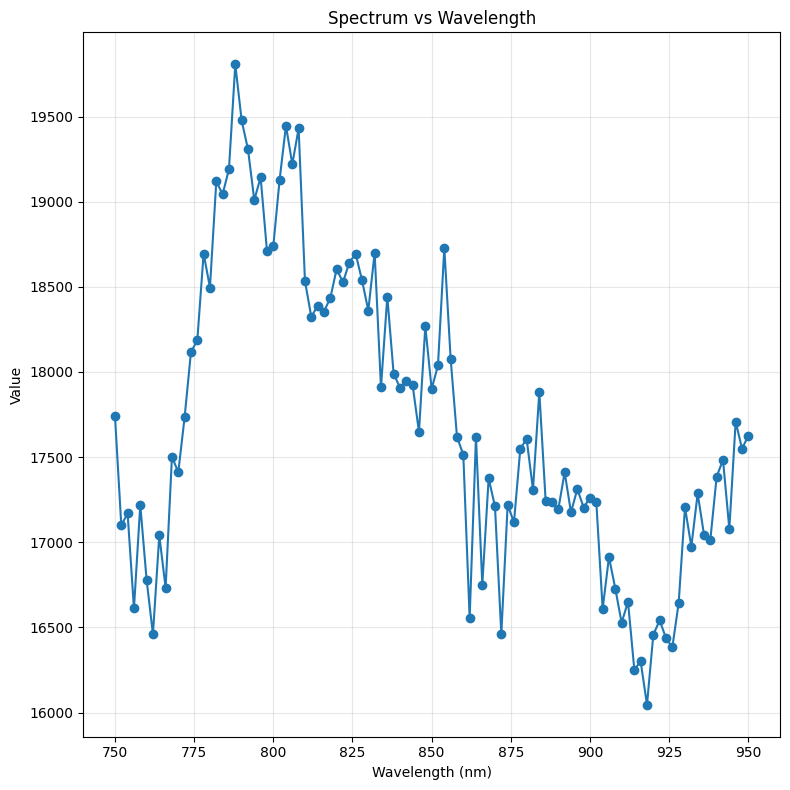

In [ ]:
import matplotlib.pyplot as plt

# Your data: 101 values
y = obj[30]

# Wavelength axis: 750, 752, ..., 950 (101 values)
wavelengths = list(range(750, 951, 2))

# (Optional) sanity check
assert len(y) == len(wavelengths) == 101, "Data must have 101 elements."

plt.figure(figsize=(8, 8))
plt.plot(wavelengths, y, marker='o')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Value")
plt.title("Spectrum vs Wavelength")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
